<a href="https://colab.research.google.com/github/aniray2908/ML-foundations-rebuild/blob/main/interpretability/demos/shap_explanations_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SHAP Explanations Demo

This notebook demonstrates how SHAP values explain individual predictions of machine learning models.

We explore:

- Local feature attribution
- Global feature importance
- SHAP summary plots
- SHAP dependence plots

These experiments illustrate how SHAP decomposes model predictions into additive feature contributions.

In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

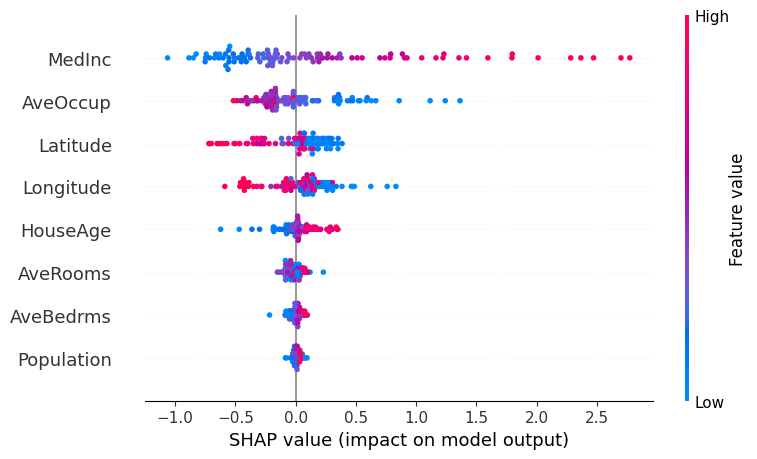

In [9]:
# Use a subset of the test data for SHAP explanations
X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)

## Local Explanation

SHAP values explain how each feature contributed to a specific prediction.

The waterfall plot shows how the prediction moves from the baseline value to the final prediction.

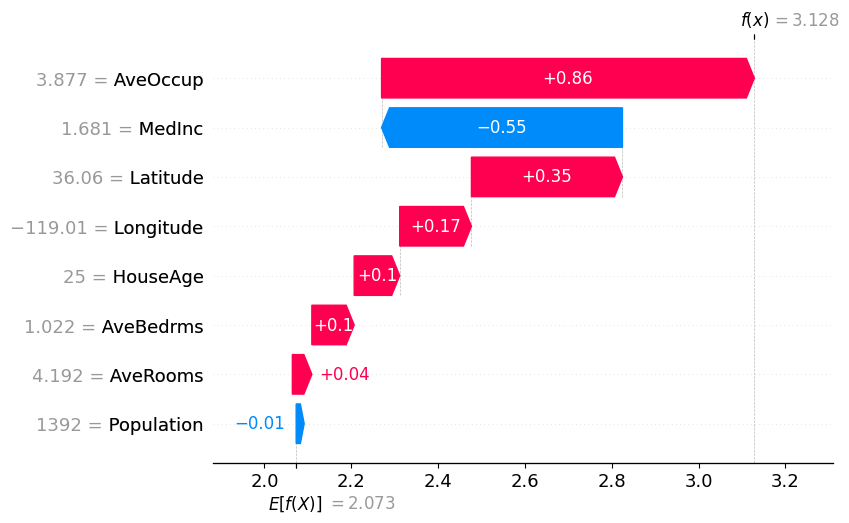

In [10]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## Global Feature Importance

Aggregating SHAP values across many observations reveals which features influence the model most.

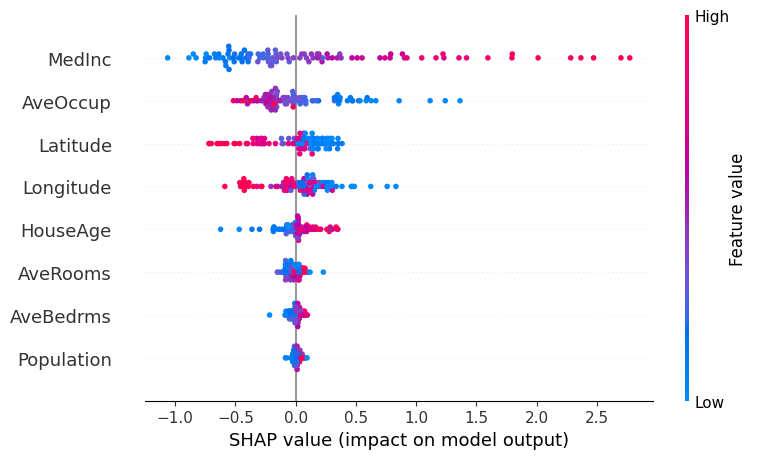

In [13]:
# Sample smaller dataset for SHAP (for speed)
X_sample = X_test.sample(100, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

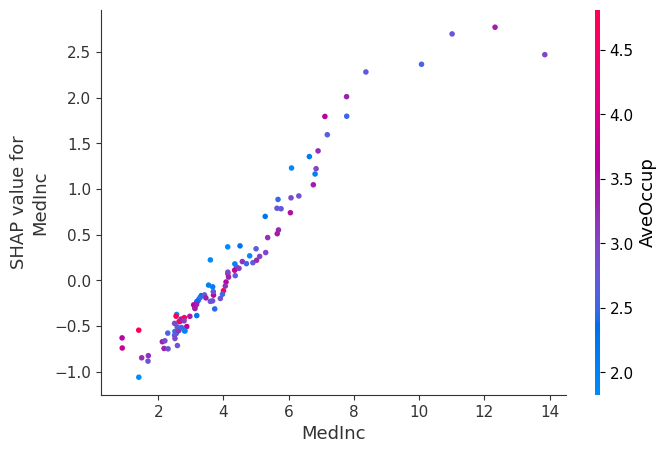

In [15]:
shap.dependence_plot(
    "MedInc",
    shap_values,
    X_sample
)

# Key Observations

This notebook demonstrates how SHAP explains machine learning predictions.

Key insights:

- SHAP decomposes predictions into additive feature contributions.
- Waterfall plots explain individual predictions.
- Summary plots reveal global feature importance.
- Dependence plots visualize feature effects and interactions.

SHAP therefore bridges the gap between:

- feature importance (global explanations)
- partial dependence (feature effects)
- instance-level reasoning (local explanations)

This makes SHAP one of the most powerful interpretability tools in modern machine learning.